# Supplementary Figure 1: Plot all stimuli

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
import os
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from IPython.core.display_functions import clear_output
import pickle
import seaborn as sns
from matplotlib.patches import Rectangle, Circle

# Load data

In [3]:
# from all_gcl_manuscript.utils import restore_numpy_arrays
# from all_gcl_manuscript.paths import DATASET_DIR, ALL_GCL_TABLE

# all_gcl_df = pd.read_parquet(os.path.join(DATASET_DIR, ALL_GCL_TABLE))
# all_gcl_df = restore_numpy_arrays(all_gcl_df)

In [43]:
all_gcl_df = pd.read_pickle('/gpfs01/euler/data/SharedFiles/projects/all-GCL/database-v2-test/all_RGC_table_2026_05_08.pkl')

In [45]:
def reshape_matrix(x, n_out):
    T, N = x.shape
    assert N % n_out == 0
    x = x.T
    x = x.reshape(n_out, -1, T)
    x = x.reshape(n_out, -1)
    x = x.T
    return x
    
def plot_triggers(ax, triggertimes, ymin, ymax, lw=1, alpha=0.75):
    for tt in triggertimes:
        ax.vlines(tt, ymin, ymax, color='tab:red', lw=lw, alpha=alpha, zorder=-5)

def plot_preprocessed_trace(ax, row, prefix='chirp_'):
    trace = row[f"{prefix}pp_trace"]
    trace_t0 = row[f"{prefix}pp_trace_t0"]
    trace_dt = row[f"{prefix}pp_trace_dt"]
    if f"{prefix}triggertimes" in row:
        triggertimes = row[f"{prefix}triggertimes"]
    else:
        triggertimes = row[f"{prefix}triggertimes_snippets"]
    
    trace_ts = np.arange(trace.size) * trace_dt + trace_t0

    ax.plot(trace_ts, trace)
    plot_triggers(ax, triggertimes, ymin=trace.min(), ymax=trace.max())

    ax.set(xlabel='Absolute time (s)', ylabel='Preprocessed\ntrace')


def preprocessed_trace(row, prefix='chirp_'):
    trace = row[f"{prefix}pp_trace"]
    trace_t0 = row[f"{prefix}pp_trace_t0"]
    trace_dt = row[f"{prefix}pp_trace_dt"]
    if f"{prefix}triggertimes" in row:
        triggertimes = row[f"{prefix}triggertimes"]
    else:
        triggertimes = row[f"{prefix}triggertimes_snippets"]
    
    trace_ts = np.arange(trace.size) * trace_dt + trace_t0

    return trace_ts, trace, triggertimes

def preprocessed_snippets(row, prefix='chirp_'):
    trace = row[f"{prefix}snippets"]              # (T, N)
    trace_t0 = row[f"{prefix}snippets_t0"]        # (N,)
    trace_dt = row[f"{prefix}snippets_dt"]
    triggertimes = np.array(row[f"{prefix}triggertimes_snippets"])  # (2, N)

    T, N = trace.shape

    # -------------------- time axis per trial --------------------
    t = np.arange(T) * trace_dt                   # (T,)
    trace_ts = t[:, None] + trace_t0[None, :]     # (T, N)

    # -------------------- sanity check --------------------
    assert triggertimes.shape[1] == N, \
        f"Trigger mismatch: {triggertimes.shape} vs trials {N}"

    return trace_ts, trace, triggertimes

# load stimuli

In [46]:
# stimuli data: https://github.com/eulerlab/QDSpy-stimuli-Documentation
with open('chirp_stim.pickle', 'rb') as f:
    chirp_stim = pickle.load(f)
chirp_stim = chirp_stim[0]['stimulus_trace']
chirp_int_stim = np.hstack((chirp_stim,chirp_stim))

with open('csl_stim.pickle', 'rb') as f:
    csl_stim = pickle.load(f)
csl_stim = csl_stim[0]['stimulus_trace']

with open('noise_stim.pickle', 'rb') as f:
    noise_stim = pickle.load(f)
noise_stim = noise_stim[0]['stimulus_trace']

In [47]:
def generate_center_surround_stimulus(
    n_frames=200,
    durStim=0.2,
    seed=0,
    intensity_scale=1.0
):
    """
    Returns:
        t              : time vector (s)
        center         : center intensity trace
        surround       : surround intensity trace
        trigger_times  : trigger timestamps (s)
    """
    
    np.random.seed(seed)

    # binary M-sequence-like signals (placeholder)
    center = np.random.choice([0, 1], size=n_frames) * intensity_scale
    surround = np.random.choice([0, 1], size=n_frames) * intensity_scale

    # time axis
    t = np.arange(n_frames) * durStim

    # triggers (one per stimulus step)
    trigger_times = t.copy()

    return {
        "t": t,
        "center": center,
        "surround": surround,
        "trigger_times": trigger_times
    }

def plot_center_surround_annulus(
    ax,
    center_radius=0.3,
    inner_radius=0.4,
    outer_radius=1.0,
    center_color='#4da6ff',     # UV (blue)
    surround_color='#4da6ff',
    center_alpha=0.9,
    surround_alpha=0.25,
    draw_outline=False,
    outline_lw=1.5
):
    """
    Draws a center + annulus (center-surround) pictogram into a given axis.

    Parameters
    ----------
    ax : matplotlib axis
    center_radius : float
    inner_radius : float
    outer_radius : float
    colors : UV blue by default
    draw_outline : bool (if True, draws clean line-style instead of filled)
    """

    theta = np.linspace(0, 2*np.pi, 400)

    if draw_outline:
        # outline style (very clean for papers)
        ax.plot(outer_radius*np.cos(theta), outer_radius*np.sin(theta),
                color=surround_color, lw=outline_lw)
        ax.plot(inner_radius*np.cos(theta), inner_radius*np.sin(theta),
                color=surround_color, lw=outline_lw)
        ax.plot(center_radius*np.cos(theta), center_radius*np.sin(theta),
                color=center_color, lw=outline_lw)
    else:
        # filled annulus
        ax.fill(outer_radius*np.cos(theta), outer_radius*np.sin(theta),
                color=surround_color, alpha=surround_alpha, edgecolor=None)

        ax.fill(inner_radius*np.cos(theta), inner_radius*np.sin(theta),
                color='white', edgecolor=None)

        ax.fill(center_radius*np.cos(theta), center_radius*np.sin(theta),
                color=center_color, alpha=center_alpha)

    # styling
    ax.set_aspect('equal')
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.axis('off')

In [48]:
# center-surround
stim = generate_center_surround_stimulus()

t_bg = stim["t"]
center_bg = stim["center"]
surround_bg = stim["surround"]
triggers_bg = stim["trigger_times"]

In [49]:
# Moving bar stimulus
movingbar = np.load("RGC_MovingBar_60Hz_10um_pixels.npy")
movingbar_mark = np.load("RGC_MovingBar_60Hz_10um_pixels_mark.npy")
movingbar = np.round(np.mean(movingbar, axis=-1)).astype(int)
movingbar[2*60, 0, 0]

movingbar_mark = np.append(movingbar_mark[:-1] & (~movingbar_mark[1:]), False)
time_movingbar = np.arange(movingbar.shape[0]) * 1./60.

In [50]:
# SpotSize stimulus
spotsize = np.load("SpotsSize_60Hz_10um_pixels.npy")
spotsize_mark = np.load("SpotsSize_60Hz_10um_pixels_mark.npy")
time_spots = np.arange(spotsize.shape[0]) * 1./60.

valid_idx = np.where(np.any(spotsize > 0, axis=(1,2,3)))[0]
spot_onsets = np.array([valid_idx[0]] + [idx for idx in valid_idx[1:] if idx - valid_idx[np.where(valid_idx == idx)[0][0]-1] > 100])
spots_concat = np.concatenate(spotsize[spot_onsets], axis=1)
spotsize = np.round(np.mean(spotsize, axis=-1)).astype(int)

In [52]:
# natural movies
nm = np.load("mcv3_setup1.npz")
mc15 = nm['arr_0']

# Plot data

In [53]:
for stim in ['chirp', 'bar', 'mc', 'csl', 'blue', 'noise',  'shifty_noise','spots']:
    print(stim)
    print([c for c in all_gcl_df.columns if c.lower().startswith(stim) or c.lower().endswith(stim)])

chirp
['chirp_on_off_index', 'chirp_transience_index', 'chirp_qidx', 'chirp_pres_qidx', 'chirp_8Hz_average_norm', 'chirp_8Hz_average_dt', 'chirp_trace', 'chirp_trace_t0', 'chirp_trace_dt', 'chirp_pp_trace', 'chirp_pp_trace_t0', 'chirp_pp_trace_dt', 'chirp_snippets', 'chirp_snippets_t0', 'chirp_snippets_dt', 'chirp_triggertimes_snippets', 'chirp_60Hz_average_norm', 'chirp_60Hz_average_dt', 'chirpInt_trace', 'chirpInt_trace_t0', 'chirpInt_trace_dt', 'chirpInt_pp_trace', 'chirpInt_pp_trace_t0', 'chirpInt_pp_trace_dt', 'chirpInt_snippets', 'chirpInt_snippets_t0', 'chirpInt_snippets_dt', 'chirpInt_triggertimes_snippets', 'chirpInt_60Hz_average_norm', 'chirpInt_60Hz_average_dt', 'chirpInt_8Hz_average_norm', 'chirpInt_8Hz_average_dt', 'chirpInt_qidx']
bar
['bar_ds_index', 'bar_ds_pvalue', 'bar_pref_dir', 'bar_os_index', 'bar_os_pvalue', 'bar_pref_or', 'bar_qidx', 'bar_pres_qidx', 'bar_trace', 'bar_trace_t0', 'bar_trace_dt', 'bar_pp_trace', 'bar_pp_trace_t0', 'bar_pp_trace_dt', 'bar_snippets',

# plotting

In [55]:
chirp_1 = all_gcl_df[(all_gcl_df.chirp_qidx>0.8) & (all_gcl_df.chirp_trace.notnull())].iloc[0]
trace_ts_chirp_1, trace_chirp_1, triggertimes_chirp_1 = preprocessed_snippets(chirp_1,prefix='chirp_')

bar_1 = all_gcl_df[(all_gcl_df.bar_qidx>0.8) & (all_gcl_df.bar_trace.notnull())].iloc[0]
trace_ts_bar_1, trace_bar_1, triggertimes_bar_1 = preprocessed_snippets(bar_1,prefix='bar_')
bar_traces = reshape_matrix(trace_bar_1,3)

chirp_int_1 = all_gcl_df[(all_gcl_df.chirp_qidx > 0.6) & (all_gcl_df.bar_qidx > 0.8) & (all_gcl_df.chirpInt_trace.notnull())].iloc[0]
trace_ts_chirp_int_1, trace_chirp_int_1, triggertimes_chirp_int_1 = preprocessed_snippets(chirp_int_1,prefix='chirpInt_')

csl_1 = all_gcl_df[(all_gcl_df.chirp_qidx > 0.6) & (all_gcl_df.bar_qidx > 0.7) & (all_gcl_df.csl_trace.notnull())].iloc[0]
trace_ts_csl_1, trace_csl_1, triggertimes_csl_1 = preprocessed_snippets(csl_1,prefix='csl_')

########## noise
noise_1 = all_gcl_df[(all_gcl_df.chirp_qidx>0.6) & (all_gcl_df.bar_qidx>0.7) & (all_gcl_df.noise_trace.notnull())].iloc[0]
prefix='noise_'
rf = noise_1[f"{prefix}rf"]
srf = noise_1[f"{prefix}srf"]
trf = noise_1[f"{prefix}trf"]
rf_time = noise_1[f"{prefix}rf_time"]
vabsmax = np.max(np.abs(rf))
h, w = rf.shape[1:3]
extent = (0, w, 0, h)

trace_ts_noise, trace_noise, triggertimes_noise = preprocessed_trace(noise_1,prefix='noise_')

########## shifty noise
shifty_noise_1 = all_gcl_df[(all_gcl_df.chirp_qidx>0.6) & (all_gcl_df.bar_qidx>0.7) & (all_gcl_df.shifty_noise_trace.notnull())].iloc[0]
prefix='shifty_noise_'

shifty_rf = shifty_noise_1[f"{prefix}rf"]
shifty_srf = shifty_noise_1[f"{prefix}srf"]
shifty_trf = shifty_noise_1[f"{prefix}trf"]
shifty_rf_time = shifty_noise_1[f"{prefix}rf_time"]
shifty_vabsmax = np.max(np.abs(shifty_rf))
shifty_h, shifty_w = shifty_rf.shape[1:3]
shifty_extent = (0, shifty_w, 0, shifty_h)

trace_ts_shifty_noise, trace_shifty_noise, triggertimes_shifty_noise = preprocessed_trace(shifty_noise_1,prefix='shifty_noise_')


#### Blue-center-surround
bg_1 = all_gcl_df[(all_gcl_df.chirp_qidx>0.6) & (all_gcl_df.bar_qidx>0.7) & (all_gcl_df.blue_trace.notnull())].iloc[0]
trace_ts_bg, trace_bg, triggertimes_bg = preprocessed_trace(bg_1,prefix='blue_')
prefix='blue_'

rf_bg = bg_1[f"{prefix}rf"]
rf_time_bg = bg_1[f"{prefix}rf_time"]

trf_center = rf_bg[:, 0, 0]
trf_surround = rf_bg[:, 1, 0]
vabsmax_bg = np.max(np.abs(rf_bg))


#### Green-center-surround
g_1 = all_gcl_df[(all_gcl_df.chirp_qidx>0.6) & (all_gcl_df.bar_qidx>0.7) & (all_gcl_df.green_trace.notnull())].iloc[0]
trace_ts_g, trace_g, triggertimes_g = preprocessed_trace(g_1,prefix='green_')
prefix='green_'

rf_g = g_1[f"{prefix}rf"]
rf_time_g = g_1[f"{prefix}rf_time"]

trf_center_g = rf_g[:, 0, 0]
trf_surround_g = rf_g[:, 1, 0]
vabsmax_g = np.max(np.abs(rf_g))

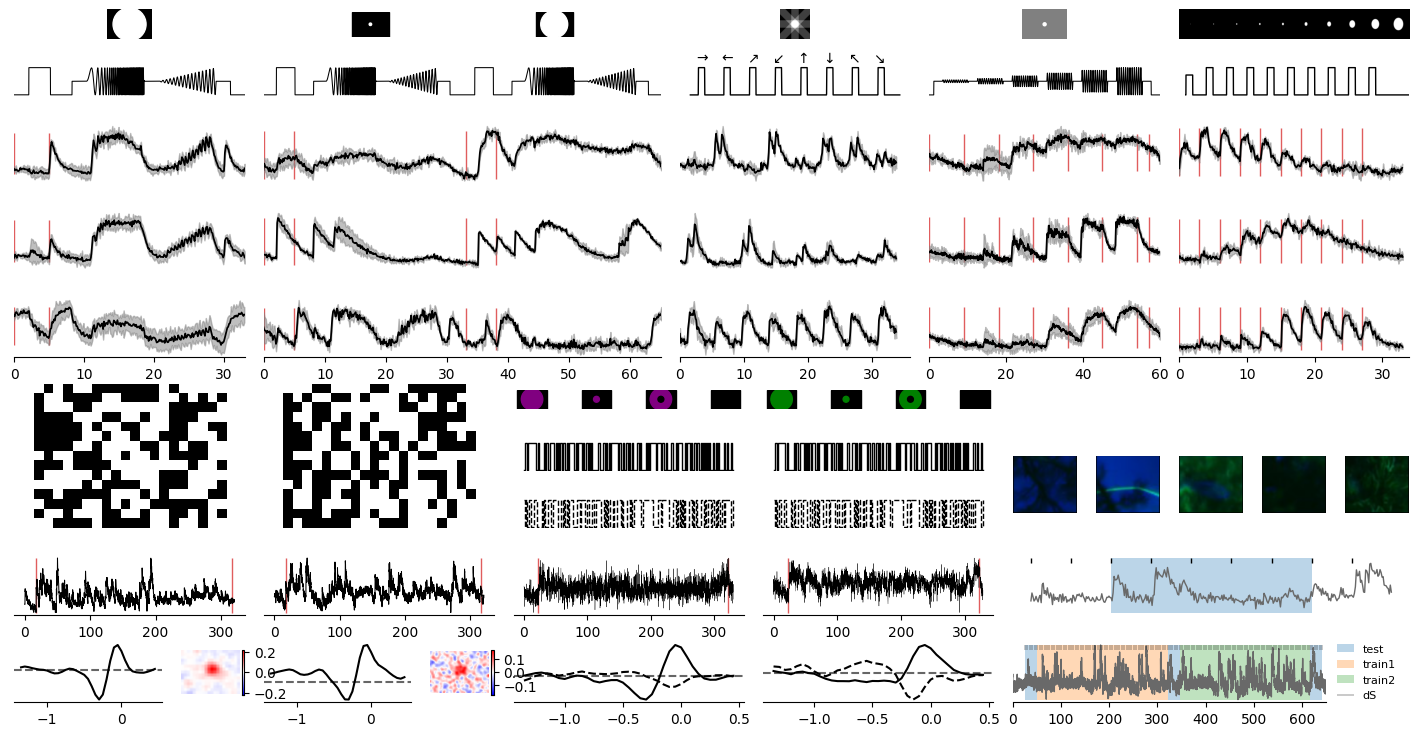

In [138]:
lw = 1.25
sf = 7.81

fig, axs = plt.subplot_mosaic(
    """
    .a..bbb..c..d.eee
    fffgggggzzziiijjj
    kkklllllmmmnnnooo
    pppqqqqqrrrsssttt
    uuuvvvvvwwwxxxyyy
    AAABBBCCCGGG.....
    AAABBBEEEIII12345
    AAABBBFFFJJJ12345
    LLLOOORRRTTTVVVVV
    MMNPPQSSSUUUWWWW.


    
    """,
    height_ratios=(0.5, 0.5, 1, 1, 1, 0.5, 0.5, 0.5, 1, 1),
    figsize=(18, 9)
)


# -------------------- Stimuli (TIME-ALIGNED) --------------------

# -------------------- Full-field chirp
axs['a'].add_patch(Rectangle((0, 0), 1.5, 1, color='black'))
axs['a'].add_patch(Circle((.75, 0.5), 0.55, color='white'))
axs['a'].set_xlim(0, 1.5)
axs['a'].set_ylim(0, 1)
axs['a'].set_aspect('equal')

t_chirp = np.linspace(0, len(chirp_stim)/sf, len(chirp_stim))
t_chirp = np.linspace(0, 33, len(chirp_stim))
axs['f'].plot(t_chirp, chirp_stim, color='k', lw=0.75)
axs['f'].set_xlim(0,33)


# -------------------- Chirp Interleaved
gap, w, h = 6, 1.5, 1
radii = [0.05, 0.55] 
for x,r in zip([0,w+gap], radii):
    axs['b'].add_patch(Rectangle((x,0), w,h, color='black'))
    axs['b'].add_patch(Circle((x+w/2, h/2), r, color='white'))
axs['b'].set_xlim(-0.2, 2*w+gap+0.2)
axs['b'].set_ylim(0,h)
axs['b'].set_aspect('equal')

for key in ['a','b','c','d','e']:
    axs[key].set_aspect('equal', adjustable='box')
t_chirp_int = np.linspace(0, len(chirp_int_stim)/sf, len(chirp_int_stim))
t_chirp_int = np.linspace(0, 66, len(chirp_int_stim))
axs['g'].plot(t_chirp_int, chirp_int_stim, color='k', lw=0.75)
axs['g'].set_xlim(0,66)

# -------------------- Moving Bar Stimulus --------------------
h, w = movingbar.shape[1:3]
im = axs['c'].imshow(np.mean(movingbar, axis=0), vmin=0, extent=(-w/2, w/2, h/2, -h/2),cmap='gray')

axs['z'].plot(time_movingbar[200:], movingbar[200:, movingbar.shape[1] // 2, movingbar.shape[2] // 2], color='k', lw=1)
arrow_labels = ['→', '←', '↗', '↙', '↑', '↓', '↖', '↘']
for i, arrow in enumerate(arrow_labels):
    axs['z'].text((5.15 + 4*i), 280, arrow, ha='center', va='bottom', fontsize=10)

# -------------------- CSL
t_csl = np.linspace(0, len(csl_stim)/sf, len(csl_stim))
t_csl = np.linspace(0, 60, len(csl_stim))
axs['i'].plot(t_csl, csl_stim, color='k', lw=0.75)
axs['i'].set_xlim(0, 60)

axs['d'].add_patch(Rectangle((0, 0), 1.5, 1, color='gray'))
axs['d'].add_patch(Circle((.75, 0.5), 0.05, color='white'))
axs['d'].set_xlim(0, 1.5)
axs['d'].set_ylim(0, 1)
axs['d'].set_aspect('equal')


# -------------------- SpotSize Stimulus --------------------
axs['j'].plot(time_spots[60:], spotsize[60:, spotsize.shape[1]//2, spotsize.shape[2]//2], c='k', lw=1)
axs['j'].set_xlim(0,34)
axs['e'].imshow(spots_concat, cmap='gray', vmin=0, vmax=255, aspect='auto',extent=axs['j'].get_xlim() + (spots_concat.shape[0], 0))
axs['e'].set_aspect('auto')

# -------------------- Noise & Shifty Noise
axs['A'].imshow(noise_stim[:, :, 0], cmap='binary')
axs['A'].set_aspect('equal')
axs['B'].imshow(noise_stim[:, :, 1], cmap='binary')
axs['B'].set_aspect('equal')

# -------------------- Center-surround 
axs['E'].step(t_bg, center_bg, where='post', color='black', lw=1)
axs['F'].step(t_bg, surround_bg, where='post', color='black', lw=1, linestyle='--')

axs['I'].step(t_bg, center_bg, where='post', color='black', lw=1)
axs['J'].step(t_bg, surround_bg, where='post', color='black', lw=1, linestyle='--')

# UV
gap,w,h = 1.8,1.5,1
r_small,r_big = 0.15,0.55
xs = [i*(w+gap) for i in range(4)]
axs['C'].add_patch(Rectangle((xs[0],0),w,h,color='black'))
axs['C'].add_patch(Circle((xs[0]+w/2,h/2),r_big,color='purple'))
axs['C'].add_patch(Rectangle((xs[1],0),w,h,color='black'))
axs['C'].add_patch(Circle((xs[1]+w/2,h/2),r_small,color='purple'))
axs['C'].add_patch(Rectangle((xs[2],0),w,h,color='black'))
axs['C'].add_patch(Circle((xs[2]+w/2,h/2),r_big,color='purple'))
axs['C'].add_patch(Circle((xs[2]+w/2,h/2),r_small,color='black'))
axs['C'].add_patch(Rectangle((xs[3],0),w,h,color='black'))
axs['C'].set_xlim(-0.2,xs[-1]+w+0.2)
axs['C'].set_ylim(0,h)
axs['C'].set_aspect('equal')

# Green
gap,w,h = 1.8,1.5,1
r_small,r_big = 0.15,0.55
xs = [i*(w+gap) for i in range(4)]
axs['G'].add_patch(Rectangle((xs[0],0),w,h,color='black'))
axs['G'].add_patch(Circle((xs[0]+w/2,h/2),r_big,color='green'))
axs['G'].add_patch(Rectangle((xs[1],0),w,h,color='black'))
axs['G'].add_patch(Circle((xs[1]+w/2,h/2),r_small,color='green'))
axs['G'].add_patch(Rectangle((xs[2],0),w,h,color='black'))
axs['G'].add_patch(Circle((xs[2]+w/2,h/2),r_big,color='green'))
axs['G'].add_patch(Circle((xs[2]+w/2,h/2),r_small,color='black'))
axs['G'].add_patch(Rectangle((xs[3],0),w,h,color='black'))
axs['G'].set_xlim(-0.2,xs[-1]+w+0.2)
axs['G'].set_ylim(0,h)
axs['G'].set_aspect('equal')


# -------------------- TRACES -------------------------------
# -------------------- CHIRP --------------------
chirp_cells = all_gcl_df[
    (all_gcl_df.chirp_qidx > 0.8) &
    (all_gcl_df.chirp_trace.notnull())
].iloc[[1, 40, 10]]

for row, ax_key in zip(chirp_cells.itertuples(index=False), ['k','p','u']):
    ax = axs[ax_key]

    ts, trace, trig = preprocessed_snippets(row._asdict(), prefix='chirp_')

    t0 = trig[0, 0]
    t = ts[:, 0] - t0
    trig_plot = trig[:, 0] - t0

    mean_trace = trace.mean(axis=1)
    std_trace  = trace.std(axis=1)

    ax.plot(t, mean_trace, color='k', lw=lw)
    ax.fill_between(t, mean_trace+std_trace, mean_trace-std_trace,
                    color='gray', alpha=0.5)

    plot_triggers(ax, trig_plot, mean_trace.min(), mean_trace.max())

    ax.set_xlim(0,33)


# -------------------- CHIRP INTERLEAVED --------------------
chirp_int_cells = all_gcl_df[
    (all_gcl_df.chirp_qidx > 0.6) &
    (all_gcl_df.bar_qidx > 0.8) &
    (all_gcl_df.chirpInt_trace.notnull())
].iloc[[9, 40, 11]]

for row, ax_key in zip(chirp_int_cells.itertuples(index=False), ['l','q','v']):
    ax = axs[ax_key]

    ts, trace, trig = preprocessed_snippets(row._asdict(), prefix='chirpInt_')

    t0 = trig[0, 0]
    t = ts[:, 0] - t0
    trig_plot = trig[:, 0] - t0

    mean_trace = trace.mean(axis=1)
    std_trace  = trace.std(axis=1)

    ax.plot(t, mean_trace, color='k', lw=lw)
    ax.fill_between(t, mean_trace+std_trace, mean_trace-std_trace,
                    color='gray', alpha=0.5)

    plot_triggers(ax, trig_plot, mean_trace.min(), mean_trace.max())
    ax.set_xlim(0,65)

# -------------------- MOVING BAR --------------------
bar_cells = all_gcl_df[
    (all_gcl_df.bar_qidx > 0.8) &
    (all_gcl_df.bar_trace.notnull())
].iloc[[9, 42, 11]]

for row, ax_key in zip(bar_cells.itertuples(index=False), ['m','r','w']):
    ax = axs[ax_key]

    ts, trace, trig = preprocessed_snippets(row._asdict(), prefix='bar_')

    trace_rs = reshape_matrix(trace, 3)

    mean_trace = trace_rs.mean(axis=1)
    std_trace  = trace_rs.std(axis=1)

    t = np.linspace(0, len(mean_trace)/sf, len(mean_trace))

    ax.plot(t, mean_trace, color='k', lw=lw)
    ax.fill_between(t, mean_trace+std_trace, mean_trace-std_trace,
                    color='gray', alpha=0.5)

    ax.set_xlim(0, 36)

# -------------------- CSL --------------------
csl_cells = all_gcl_df[
    (all_gcl_df.csl_qidx > 0.8) &
    (all_gcl_df.csl_trace.notnull())
].iloc[[1,2,3]]

for row, ax_key in zip(csl_cells.itertuples(index=False), ['n','s','x']):
    ax = axs[ax_key]

    ts, trace, trig = preprocessed_snippets(row._asdict(), prefix='csl_')

    t0 = trig[0, 0]
    t = ts[:, 0] - t0
    trig_plot = trig[:, 0] - t0

    mean_trace = trace.mean(axis=1)
    std_trace  = trace.std(axis=1)

    ax.plot(t, mean_trace, color='k', lw=lw)
    ax.fill_between(t, mean_trace+std_trace, mean_trace-std_trace,
                    color='gray', alpha=0.5)

    plot_triggers(ax, trig_plot, mean_trace.min(), mean_trace.max())
    ax.set_xlim(0, 60)


# -------------------- Spots --------------------

spots_cells = all_gcl_df[
    (all_gcl_df.spots_qidx > 0.9) &
    (all_gcl_df.spots_trace.notnull())
].iloc[[1, 39, 10]]

for row, ax_key in zip(spots_cells.itertuples(index=False), ['o','t','y']):
    ax = axs[ax_key]
    ts, trace, trig = preprocessed_snippets(row._asdict(), prefix='spots_')
    t0 = trig[0, 0]
    t = ts[:, 0] - t0
    trig_plot = trig[:, 0] - t0
    mean_trace = trace.mean(axis=1)
    std_trace  = trace.std(axis=1)
    ax.plot(t, mean_trace, color='k', lw=lw)
    ax.fill_between(t, mean_trace+std_trace, mean_trace-std_trace,
                    color='gray', alpha=0.5)
    plot_triggers(ax, trig_plot, mean_trace.min(), mean_trace.max())

    ax.set_xlim(0, 34)


# -------------------- Noise --------------------
axs['L'].plot(trace_ts_noise, trace_noise, color='k', lw=lw-0.5)
plot_triggers(axs['L'], [triggertimes_noise[0][0], triggertimes_noise[0][-1]], trace_noise.min(), trace_noise.max())

axs['M'].plot(rf_time, trf, color='k')
axs['M'].axhline(0, linestyle='--', color='k', alpha=0.6)

imS = axs['N'].imshow(
    np.rot90(srf),
    cmap='bwr',
    vmin=-np.max(np.abs(srf)),
    vmax=np.max(np.abs(srf)),
    #extent=extent
)
cbarS = fig.colorbar(imS, ax=axs['N'], fraction=0.046, pad=0.04, shrink=0.75)
cbarS.ax.set_ylabel("", rotation=90)


# -------------------- Shifty noise --------------------
axs['O'].plot(trace_ts_shifty_noise, trace_shifty_noise, color='k', lw=lw-0.5)
plot_triggers(axs['O'], [triggertimes_shifty_noise[0][0], triggertimes_shifty_noise[0][-1]],
              trace_shifty_noise.min(), trace_shifty_noise.max())

axs['P'].plot(shifty_rf_time, shifty_trf, color='k')
axs['P'].axhline(0, linestyle='--', color='k', alpha=0.6)

imS = axs['Q'].imshow(np.rot90(shifty_srf), cmap='bwr',
                vmin=-np.max(np.abs(shifty_srf)),
                vmax=np.max(np.abs(shifty_srf)),
                #extent=shifty_extent
                     )

cbarS = fig.colorbar(imS, ax=axs['Q'], fraction=0.046, pad=0.04, shrink=0.75)
cbarS.ax.set_ylabel("", rotation=90)


# -------------------- Blue center-surround --------------------
axs['R'].plot(trace_ts_bg, trace_bg, color='k', lw=lw-1)
plot_triggers(axs['R'], [triggertimes_bg[0][0], triggertimes_bg[0][-1]], trace_bg.min(), trace_bg.max())

axs['S'].plot(rf_time_bg, trf_center, color='k')
axs['S'].plot(rf_time_bg, trf_surround, color='k', linestyle='--')
axs['S'].axhline(0, linestyle='--', color='k', alpha=0.6)

# -------------------- Green center-surround --------------------
axs['T'].plot(trace_ts_g, trace_g, color='k', lw=lw-1)
plot_triggers(axs['T'], [triggertimes_g[0][0], triggertimes_g[0][-1]], trace_g.min(), trace_g.max())

axs['U'].plot(rf_time_g, trf_center_g, color='k')
axs['U'].plot(rf_time_g, trf_surround_g, color='k', linestyle='--')
axs['U'].axhline(0, linestyle='--', color='k', alpha=0.6)

# -------------------- Natural Movies --------------------

for i,key in enumerate(['1','2','3','4','5']):
    img = mc15[i*155]
    m = np.any(img>0, axis=2)
    r,c = np.where(m.any(1))[0], np.where(m.any(0))[0]
    axs[key].imshow(np.rot90(img[r.min():r.max()+1, c.min():c.max()+1]))
    axs[key].axis('off')

cell_idx,test_i = 60,59

row = all_gcl_df[all_gcl_df.natural_movie_trace_bundles.apply(len)>0].iloc[cell_idx]
b = row.natural_movie_trace_bundles[0]

mc_trace = b['trace']
mc_time = np.arange(mc_trace.size)*b['trace_dt'] + b['trace_t0']
mc_tt = np.append(b['triggertimes'], b['triggertimes'][-1] + np.median(np.diff(b['triggertimes'])))
mc_ylim = (mc_trace.min(), mc_trace.max())
ilim = (mc_time >= mc_tt[test_i]-10) & (mc_time <= mc_tt[test_i+5]+10)
axs['V'].plot(mc_time[ilim], mc_trace[ilim], c='dimgray', lw=1)
axs['V'].fill_between([mc_tt[test_i],mc_tt[test_i+5]], *mc_ylim, color='C0', alpha=0.3, lw=0, label='test')
axs['V'].vlines(mc_tt[test_i-2:test_i+7], ymin=mc_ylim[1]-np.diff(mc_ylim)*0.1, ymax=mc_ylim[1], colors='k', lw=1)
for ti in [0,59,len(mc_tt)-6]:
    axs['W'].fill_between([mc_tt[ti],mc_tt[ti+5]], *mc_ylim, color='C0', alpha=0.3, lw=0, label='test' if ti==0 else '_')
axs['W'].fill_between([mc_tt[5],mc_tt[59]], *mc_ylim, color='C1', alpha=0.3, lw=0, label='train1')
axs['W'].fill_between([mc_tt[64],mc_tt[-6]], *mc_ylim, color='C2', alpha=0.3, lw=0, label='train2')
axs['W'].plot(mc_time, mc_trace, c='dimgray', lw=1)
axs['W'].vlines(mc_tt, ymin=mc_ylim[1]-np.diff(mc_ylim)*0.1, ymax=mc_ylim[1], colors='k', lw=0.3, label='dS')
axs['W'].legend(bbox_to_anchor=(1.02,0.5), loc='center left', borderaxespad=0., frameon=False, handlelength=1.5, fontsize=8)
axs['W'].set_xlim(0,650)


# -------------------- AXIS CLEANUP --------------------
for key, ax in axs.items():
    if key in list("abcdefghijklmnopqrstzABCDEFGHIJKNQV"):
        ax.axis('off')
    else:
        ax.set_yticks([])
        ax.set_ylabel('')
        ax.spines['left'].set_visible(False)

#for j in ['u','v','w','x','y']:
#    axs[j].set_xlabel('Time [s]',fontsize=10)
sns.despine(left=True, bottom=False)
fig.subplots_adjust(hspace=0.6, wspace=0.3)

plt.show()

# Plot data distribution

In [38]:
all_gcl_df = pd.read_pickle('/gpfs01/euler/data/SharedFiles/projects/all-GCL/database-v2-test/all_RGC_table_2026_05_08.pkl')

In [68]:
for stim in ['bar','mc','csl','blue','noise','shifty_noise','spots','chirpInt']:
    cols = [c for c in all_gcl_df.columns
            if c.lower().startswith(stim) or c.lower().endswith(stim)]
    valid = all_gcl_df[cols].notnull().any(axis=1)

    print(f"{stim}: {valid.sum()} cells")

bar: 2537 cells
mc: 2537 cells
csl: 451 cells
blue: 634 cells
noise: 816 cells
shifty_noise: 262 cells
spots: 631 cells
chirpInt: 0 cells


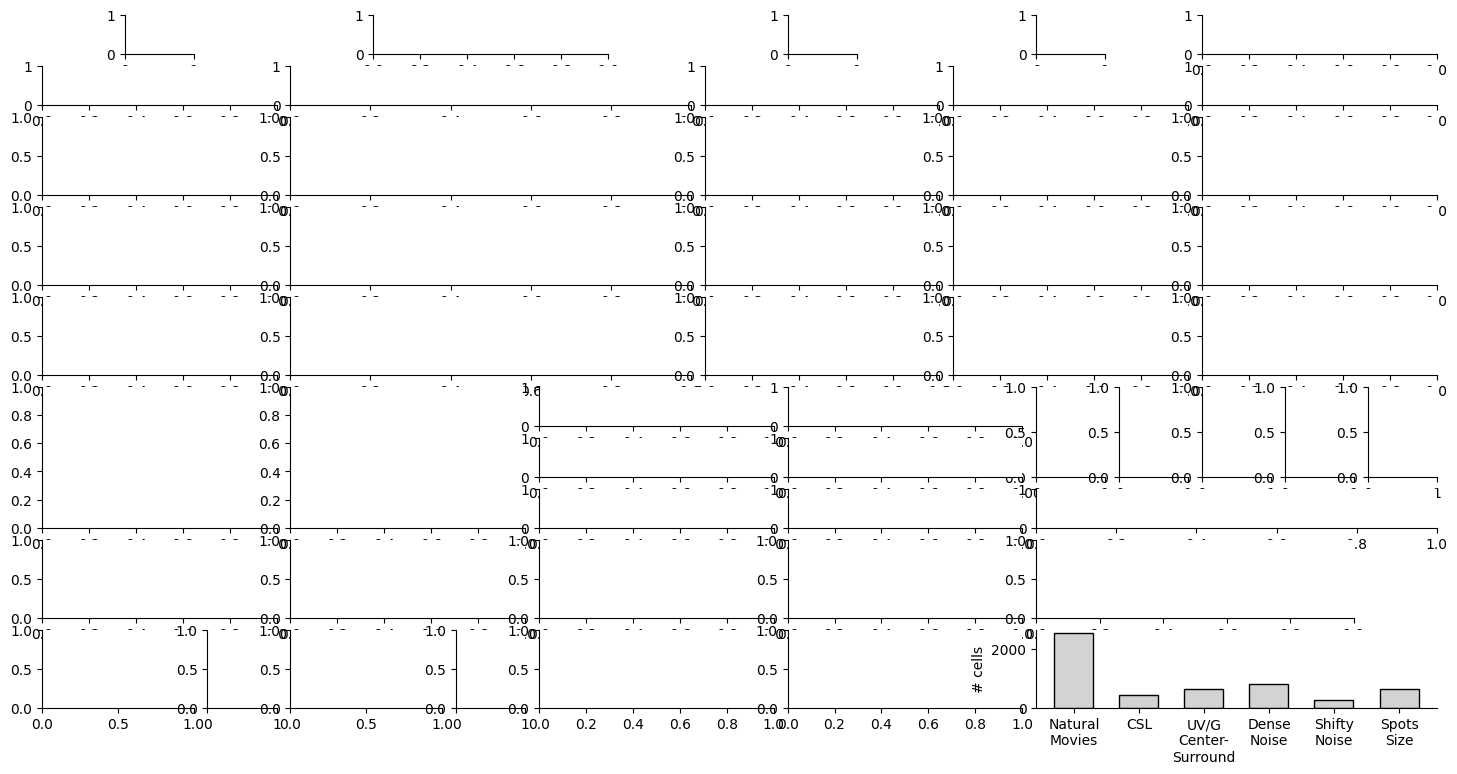

In [64]:
fig, axs = plt.subplot_mosaic(
    """
    .a..bbb..c..d.eee
    fffgggggzzziiijjj
    kkklllllmmmnnnooo
    pppqqqqqrrrsssttt
    uuuvvvvvwwwxxxyyy
    AAABBBCCCGGG12345
    AAABBBEEEIII12345
    AAABBBFFFJJJVVVVV
    LLLOOORRRTTTWWWW.
    MMNPPQSSSUUUXXXXX


    
    """,
    height_ratios=(0.5, 0.5, 1, 1, 1, 0.5, 0.5, 0.5, 1, 1),
    figsize=(18, 9)
)


stims = ['mc','csl','blue','noise','shifty_noise','spots']
counts = []
labels = ['Natural\nMovies', 'CSL', 'UV/G\nCenter-\nSurround', 'Dense\nNoise', 'Shifty\nNoise', 'Spots\nSize']
for stim in stims:
    cols = [c for c in all_gcl_df.columns
            if c.lower().startswith(stim)
            or c.lower().endswith(stim)]
    counts.append(all_gcl_df[cols].notnull().any(axis=1).sum())
axs['X'].bar(
    labels,
    counts,
    width=0.6,   
    color='lightgray',
    edgecolor='k'
)

axs['X'].set_ylabel('# cells')
axs['X'].tick_params(axis='x', rotation=0)

sns.despine()
plt.show()